Modelos cargados correctamente
Dataset: 182,938 filas | 33 columnas
Ciudades en encoders XGBoost: ['barcelona', 'euskadi', 'girona', 'madrid', 'malaga', 'mallorca', 'menorca', 'sevilla', 'valencia']
Dataset SHAP XGBoost: (1000, 17)
Features: ['ciudad_enc', 'barrio_enc', 'room_enc', 'accommodates', 'bedrooms', 'bathrooms', 'beds', 'price', 'minimum_nights', 'availability_365', 'host_is_superhost', 'host_listings_count', 'instant_bookable', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value']
Calculando valores SHAP para XGBoost (9 ciudades)...
✅ SHAP calculado
Shape valores SHAP: (1000, 17)

=== TOP 10 VARIABLES MÁS IMPORTANTES (SHAP) ===
  Superhost                 0.0454
  Ciudad                    0.0437
  Noches mínimas            0.0344
  Calidad-precio            0.0339
  Ubicación                 0.0330
  Precio/noche              0.0281
  Valoración general        0.0250
  Limpieza                  0.0249
  Anuncios host          

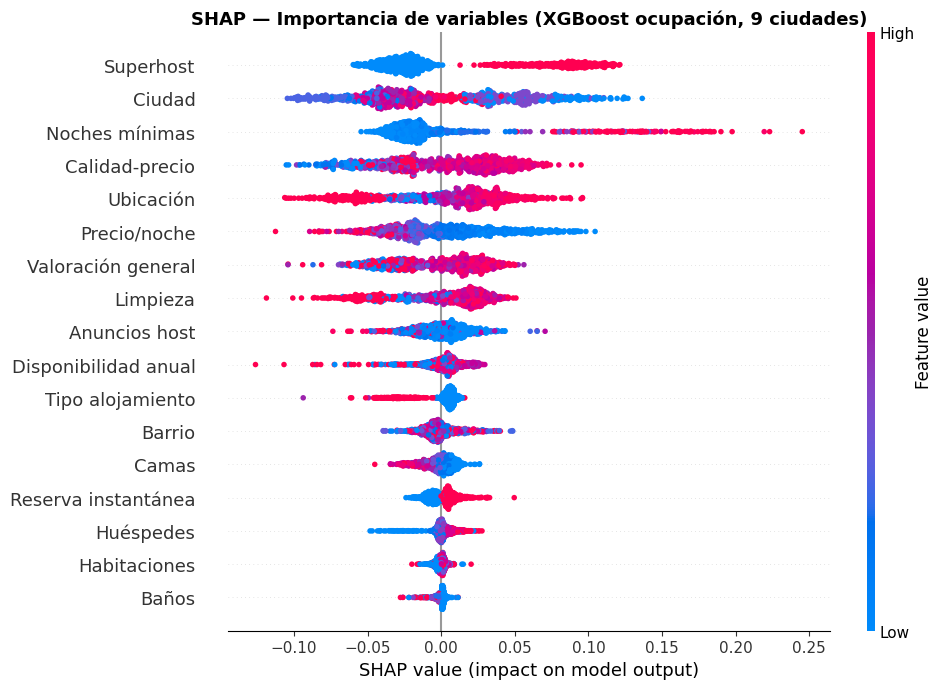

✅ Beeswarm guardado


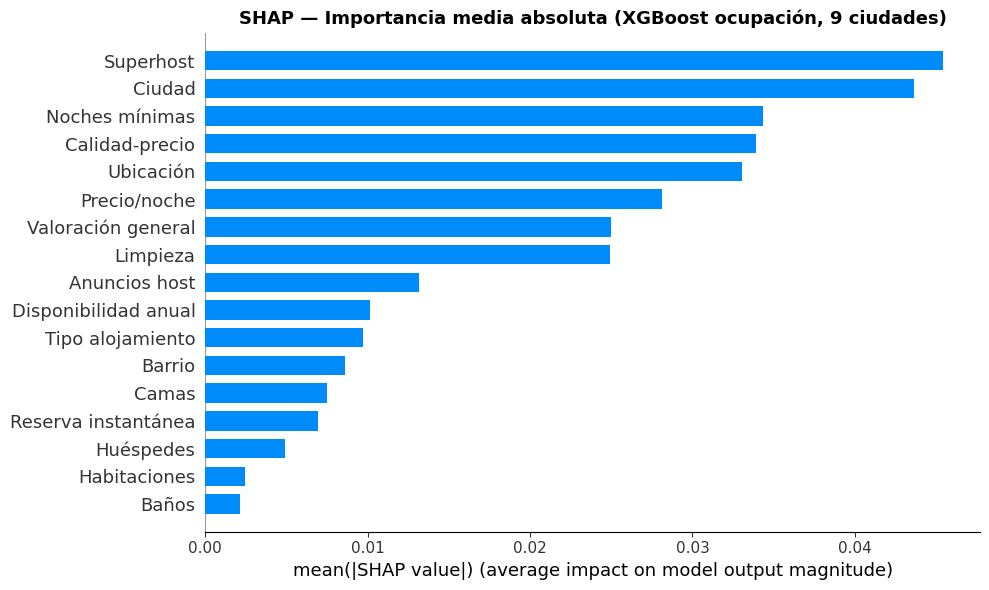

✅ Barras guardado
✅ SHAP guardado: /Users/ivannavarrosuero/tfm_vut/src/models/shap_xgb.pkl
   Tamaño: 7.3 MB

=== ESTADO FINAL src/models/ ===
  ✅ encoders_ocupacion.pkl                           0.0 MB
  ✅ encoders_rf_precio.pkl                           0.0 MB
  ✅ metricas_prophet.pkl                             0.0 MB
  ✅ metricas_rf_precio.pkl                           0.0 MB
  ✅ metricas_xgboost_ocupacion.pkl                   0.0 MB
  ✅ prophet_barcelona.pkl                            0.1 MB
  ✅ prophet_euskadi.pkl                              0.1 MB
  ✅ prophet_forecast_barcelona.pkl                   0.3 MB
  ✅ prophet_forecast_euskadi.pkl                     0.3 MB
  ✅ prophet_forecast_girona.pkl                      0.3 MB
  ✅ prophet_forecast_madrid.pkl                      0.3 MB
  ✅ prophet_forecast_malaga.pkl                      0.3 MB
  ✅ prophet_forecast_mallorca.pkl                    0.3 MB
  ✅ prophet_forecast_menorca.pkl                     0.3 MB
  ✅ prophet_forec

In [1]:
# %%
# ============================================================
# CELDA 1 — Imports y carga de modelos
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import gzip
import os
import warnings
warnings.filterwarnings('ignore')

BASE      = os.path.abspath(os.path.join(os.getcwd(), '..'))
PROCESSED = os.path.join(BASE, 'data', 'processed')
MODELS    = os.path.join(BASE, 'src', 'models')
REPORTS   = os.path.join(BASE, 'reports')

# Dataset
df = pd.read_csv(os.path.join(PROCESSED, 'listings_clean.csv'), low_memory=False)

# Modelo XGBoost y encoders (nuevo, 9 ciudades)
with open(os.path.join(MODELS, 'xgboost_ocupacion.pkl'), 'rb') as f:
    modelo_xgb = pickle.load(f)
with open(os.path.join(MODELS, 'encoders_ocupacion.pkl'), 'rb') as f:
    encoders_xgb = pickle.load(f)

# Modelo RF (comprimido)
with gzip.open(os.path.join(MODELS, 'rf_precio.pkl.gz'), 'rb') as f:
    modelo_rf = pickle.load(f)
with open(os.path.join(MODELS, 'encoders_rf_precio.pkl'), 'rb') as f:
    encoders_rf = pickle.load(f)

print("Modelos cargados correctamente")
print(f"Dataset: {df.shape[0]:,} filas | {df.shape[1]} columnas")
print(f"Ciudades en encoders XGBoost: {encoders_xgb['ciudades']}")

# %%
# ============================================================
# CELDA 2 — Preparación de datos para SHAP
# ============================================================

le_ciudad_xgb = encoders_xgb['le_ciudad']
le_barrio_xgb = encoders_xgb['le_barrio']
le_room_xgb   = encoders_xgb['le_room']
FEATURES_XGB  = encoders_xgb['features']

df_xgb = df.copy()

df_xgb['ciudad_enc'] = df_xgb['ciudad'].apply(
    lambda x: int(le_ciudad_xgb.transform([x])[0])
    if x in le_ciudad_xgb.classes_ else 0)
df_xgb['barrio_enc'] = df_xgb['neighbourhood_cleansed'].apply(
    lambda x: int(le_barrio_xgb.transform([x])[0])
    if x in le_barrio_xgb.classes_ else 0)
df_xgb['room_enc'] = df_xgb['room_type'].apply(
    lambda x: int(le_room_xgb.transform([x])[0])
    if x in le_room_xgb.classes_ else 0)

df_xgb_clean = df_xgb[FEATURES_XGB + ['ocupacion']].dropna()
X_xgb = df_xgb_clean[FEATURES_XGB]

# Muestra representativa de 1000 anuncios
X_shap_xgb = X_xgb.sample(1000, random_state=42)

print(f"Dataset SHAP XGBoost: {X_shap_xgb.shape}")
print(f"Features: {FEATURES_XGB}")

# %%
# ============================================================
# CELDA 3 — Cálculo valores SHAP
# ============================================================

print("Calculando valores SHAP para XGBoost (9 ciudades)...")

explainer_xgb    = shap.TreeExplainer(modelo_xgb)
shap_values_xgb  = explainer_xgb.shap_values(X_shap_xgb)

print(f"✅ SHAP calculado")
print(f"Shape valores SHAP: {shap_values_xgb.shape}")

# Nombres legibles
feature_names_legibles = [
    'Ciudad', 'Barrio', 'Tipo alojamiento',
    'Huéspedes', 'Habitaciones', 'Baños', 'Camas',
    'Precio/noche', 'Noches mínimas', 'Disponibilidad anual',
    'Superhost', 'Anuncios host', 'Reserva instantánea',
    'Valoración general', 'Limpieza', 'Ubicación', 'Calidad-precio'
]

print(f"\n=== TOP 10 VARIABLES MÁS IMPORTANTES (SHAP) ===")
importancia_shap = np.abs(shap_values_xgb).mean(axis=0)
indices_orden = np.argsort(importancia_shap)[::-1]
for i in indices_orden[:10]:
    print(f"  {feature_names_legibles[i]:25} {importancia_shap[i]:.4f}")

# %%
# ============================================================
# CELDA 4 — Gráficos SHAP
# ============================================================

X_shap_named = X_shap_xgb.copy()
X_shap_named.columns = feature_names_legibles

# Gráfico 1: Beeswarm (importancia global con dirección)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_xgb,
    X_shap_named,
    show=False,
    plot_size=None
)
plt.title("SHAP — Importancia de variables (XGBoost ocupación, 9 ciudades)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'shap_xgb_beeswarm.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Beeswarm guardado")

# Gráfico 2: Barras (importancia media absoluta)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_xgb,
    X_shap_named,
    plot_type='bar',
    show=False,
    plot_size=None
)
plt.title("SHAP — Importancia media absoluta (XGBoost ocupación, 9 ciudades)",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, 'shap_xgb_barras.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Barras guardado")

# %%
# ============================================================
# CELDA 5 — Guardado valores SHAP
# ============================================================

shap_data = {
    'shap_values_xgb': shap_values_xgb,
    'X_shap_xgb':      X_shap_xgb,
    'feature_names':   feature_names_legibles,
    'explainer_xgb':   explainer_xgb,
    'importancia_media': dict(zip(feature_names_legibles,
                                  importancia_shap.tolist())),
}

ruta_shap = os.path.join(MODELS, 'shap_xgb.pkl')
with open(ruta_shap, 'wb') as f:
    pickle.dump(shap_data, f)

tam = os.path.getsize(ruta_shap) / (1024*1024)
print(f"✅ SHAP guardado: {ruta_shap}")
print(f"   Tamaño: {tam:.1f} MB")

# Verificación final de todos los modelos
print(f"\n=== ESTADO FINAL src/models/ ===")
for archivo in sorted(os.listdir(MODELS)):
    tam = os.path.getsize(os.path.join(MODELS, archivo)) / (1024*1024)
    estado = "✅" if tam > 0 else "⚠️"
    print(f"  {estado} {archivo:45} {tam:6.1f} MB")